In [7]:
import matplotlib.pyplot as plt
import msprime
import numpy as np

import phasegen as pg

plt.rc('figure', figsize=(2.5, 3.5))

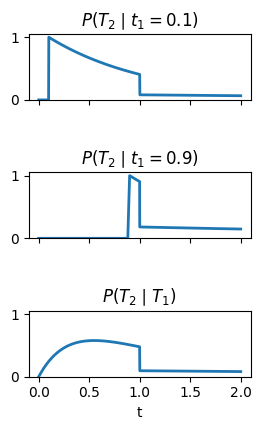

In [8]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    constrained_layout=True
)

fig.set_constrained_layout_pads(
    h_pad=0.2,
)
fig.set_size_inches(2.5, 4.5)  # width, height

def plot_with_zero_prefix(ax, coal, t0, title):
    # relative time τ
    t = np.linspace(0, 2 - t0, 1000)
    pdf = coal.tree_height.pdf(t)

    # shift to absolute time
    t_pdf = t0 + t

    # zero-density region [0, t0)
    t_left = np.linspace(0, t0, 50, endpoint=False)
    y_left = np.zeros_like(t_left)

    t_full = np.concatenate([t_left, t_pdf])
    y_full = np.concatenate([y_left, pdf])

    ax.plot(t_full, y_full, lw=2)
    ax.set_ylim(bottom=0)
    ax.set_title(title)


# t1 = 0.1
coal_01 = pg.Coalescent(
    n=2,
    demography=pg.Demography(pop_sizes={0: 1, 0.9: 5})
)
plot_with_zero_prefix(
    axes[0], coal_01, t0=0.1, title=r"$P(T_2 \mid t_1 = 0.1)$"
)

# t1 = 0.9
coal_09 = pg.Coalescent(
    n=2,
    demography=pg.Demography(pop_sizes={0: 1, 0.1: 5})
)
plot_with_zero_prefix(
    axes[1], coal_09, t0=0.9, title=r"$P(T_2 \mid t_1 = 0.9)$"
)

# unconditional P(T2 | T1)
t = np.linspace(0, 2, 1000)
pdf = pg.Coalescent(
    n=3,
    demography=pg.Demography(pop_sizes={0: 1, 1: 5})
).tree_height.pdf(t)

axes[2].plot(t, pdf, lw=2)
axes[2].set_ylim(0, axes[0].get_ylim()[1])
axes[2].set_title(r"$P(T_2 \mid T_1)$")
axes[2].set_xlabel("t")

plt.savefig("../scratch/conditional_pdfs.png", dpi=400)
plt.show()

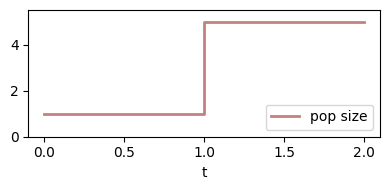

In [15]:
plt.rc('figure', figsize=(4, 2))

fig, ax = plt.subplots()

# Population size
ax.step([0, 1, 2], [1, 5, 5], where="post",
        label="pop size", color="darkred", lw=2,
        linestyle="-", alpha=0.5)

ax.set_xlabel("t")
ax.set_ylabel("")
ax.set_ylim(0, 5.5)

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../scratch/demography_example.png", dpi=400)
plt.show()

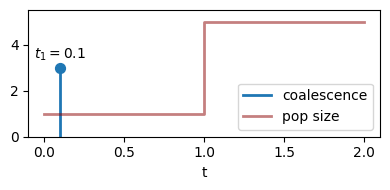

In [17]:
plt.rc('figure', figsize=(4, 2))

fig, ax = plt.subplots()

# Vertical dashed lines
ax.axvline(0.1, linestyle="-", ymin=0, ymax=3 / 5.5, linewidth=2, label="coalescence")

# Dots on x-axis
ax.scatter([0.1, 0.9], [3, 3], zorder=5, s=50)

# Extra labels near x-axis
ax.text(0.1, 3.9, "$t_1=0.1$", ha="center", va="top")

# Population size
ax.step([0, 1, 2], [1, 5, 5], where="post",
        label="pop size", color="darkred", lw=2,
        linestyle="-", alpha=0.5)

ax.set_xlabel("t")
ax.set_ylabel("")
ax.set_ylim(0, 5.5)

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../scratch/early_coal_example.png", dpi=400)
plt.show()

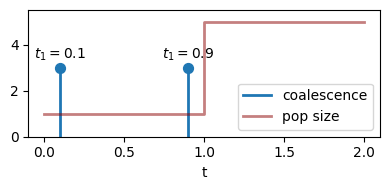

In [19]:
plt.rc('figure', figsize=(4, 2))

fig, ax = plt.subplots()

# Vertical dashed lines
ax.axvline(0.1, linestyle="-", ymin=0, ymax=3 / 5.5, linewidth=2)
ax.axvline(0.9, linestyle="-", ymin=0, ymax=3 / 5.5, linewidth=2, label="coalescence")

# Dots on x-axis
ax.scatter([0.1, 0.9], [3, 3], zorder=5, s=50)

# Extra labels near x-axis
ax.text(0.1, 3.9, "$t_1=0.1$", ha="center", va="top")
ax.text(0.9, 3.9, "$t_1=0.9$", ha="center", va="top")

# Population size
ax.step([0, 1, 2], [1, 5, 5], where="post",
        label="pop size", color="darkred", lw=2,
        linestyle="-", alpha=0.5)

ax.set_xlabel("t")
ax.set_ylabel("")
ax.set_ylim(0, 5.5)

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../scratch/late_coal_example.png", dpi=400)
plt.show()

In [ ]:
plt.rc('figure', figsize=(2.5, 1.5))

# grid
t = np.linspace(0, 2, 1000)
f = np.zeros_like(t)

# t < 1
m1 = t < 1
f[m1] = 1.5 * (np.exp(-t[m1]) - np.exp(-3 * t[m1]))

# t >= 1
m2 = t >= 1
f[m2] = (
        (3 / 10) * (np.exp(-1) - np.exp(-3)) * np.exp(-(t[m2] - 1) / 5)
        + (3 / 10) * np.exp(-3) * (np.exp(-(t[m2] - 1) / 5) - np.exp(-(3 / 5) * (t[m2] - 1)))
)

# plot
plt.plot(t, f, lw=2, color='C0')
plt.xlabel("t")
plt.xlim(0, 2)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------
# msprime simulation
# -----------------------
demography = msprime.Demography()
demography.add_population(name="pop", initial_size=1)
demography.add_population_parameters_change(
    time=1, initial_size=5, population="pop"
)

ts_iter = msprime.sim_ancestry(
    samples=3,
    ploidy=1,
    demography=demography,
    sequence_length=1,
    recombination_rate=0,
    num_replicates=10 ** 5,
)

T2 = []
for ts in ts_iter:
    tree = ts.first()
    times = sorted(
        tree.time(u)
        for u in tree.nodes()
        if tree.is_internal(u)
    )
    T2.append(times[-1])

T2 = np.array(T2)

plt.rc('figure', figsize=(2.5, 1.5))

# line density from
hist, edges = np.histogram(T2, bins=2000, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.rc('figure', figsize=(2.5, 1.5))

t = np.linspace(0, 2, 1000)
plt.plot(centers, hist, lw=2, label='msprime', color='C1')

coal = pg.Coalescent(
    n=3,
    demography=pg.Demography(pop_sizes={0: 1, 1: 5})
)

plt.plot(t, coal.tree_height.pdf(t=t), lw=2, label='theory', color='C0')

plt.axvline(1, ls="--", lw=1)
plt.xlabel("t")
plt.legend(fontsize=8)
plt.xlim(0, 2)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()